In [2]:
print("hello")

hello


In [3]:
import numpy as np
a=np.array([1, 2, 3])
b=np.array([4, 5, 6])
print(a+b)

[5 7 9]


# Downloading Dataset



In [6]:
import kagglehub
import shutil
import os

# Define your desired destination folder
destination_folder = r"E:\VS Code\ProdiyInfoTech"  # Change this path as you want

# Download latest version using kagglehub
downloaded_path = kagglehub.dataset_download("camnugent/california-housing-prices")

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Move files from kagglehub's cache to your desired folder
for item in os.listdir(downloaded_path):
    s = os.path.join(downloaded_path, item)
    d = os.path.join(destination_folder, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("Dataset copied to:", destination_folder)


Dataset copied to: E:\VS Code\ProdiyInfoTech


# Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv(r"E:\VS Code\ProdiyInfoTech\housing.csv")

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# Data Processing

## Drop the null values

In [4]:
data.dropna(inplace=True)
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


## Validation set

Dividing the data into trainning snd test sets

In [5]:
from sklearn.model_selection import train_test_split

X=data.drop(['median_house_value'], axis=1)#dataset without target variable
Y=data['median_house_value'] #target variable

In [6]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.2)


In [7]:
train_data=X_train.join(Y_train) #train data

In [8]:
X_train.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
20024,-119.06,36.07,20.0,2683.0,553.0,1497.0,548.0,1.7031,INLAND
19470,-120.99,37.67,16.0,568.0,124.0,307.0,116.0,2.1518,INLAND
1469,-121.98,37.95,14.0,6290.0,854.0,2724.0,820.0,6.7371,INLAND
2272,-119.81,36.79,39.0,2471.0,460.0,1118.0,431.0,2.4167,INLAND
12711,-121.40,38.59,25.0,2228.0,534.0,1130.0,481.0,2.5363,INLAND


In [16]:
X_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
18026,-121.92,37.25,34.0,2231.0,360.0,1035.0,365.0,4.7917,<1H OCEAN
13135,-121.43,38.47,21.0,1787.0,291.0,988.0,301.0,4.3500,INLAND
10238,-117.88,33.90,21.0,3180.0,434.0,1413.0,391.0,6.5945,<1H OCEAN
4436,-118.21,34.08,26.0,2574.0,807.0,3163.0,802.0,1.9495,<1H OCEAN
8939,-118.48,34.01,40.0,2198.0,611.0,1023.0,567.0,3.7550,<1H OCEAN


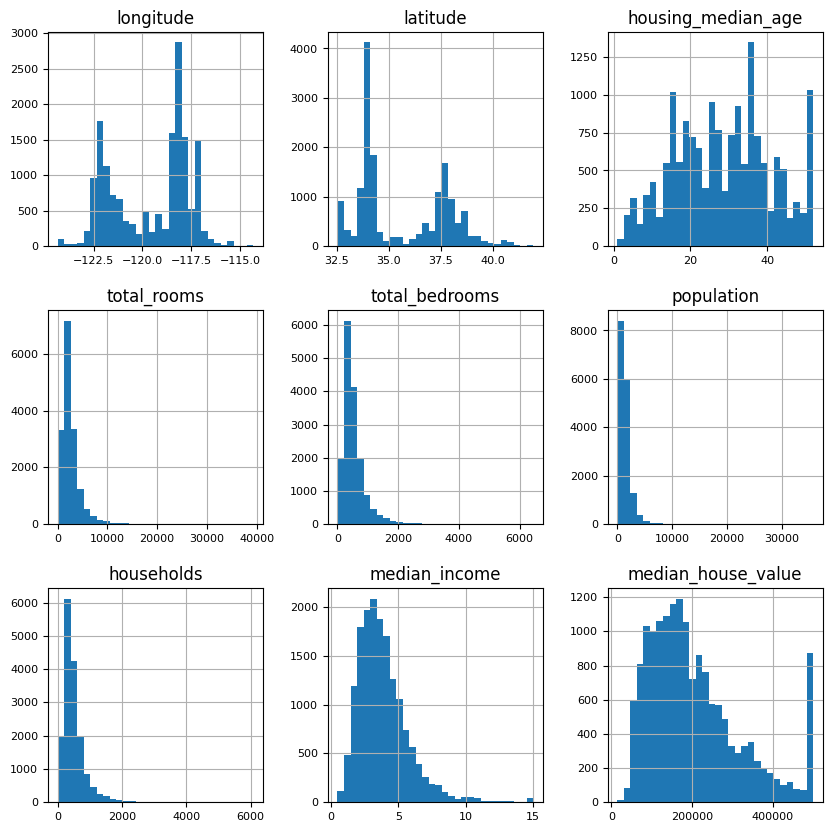

In [11]:
train_data.hist(figsize=(10, 10), bins=30, xlabelsize=8, ylabelsize=8)
plt.show()

## Correlation Matrix

<Axes: title={'center': 'Correlation Heatmap'}>

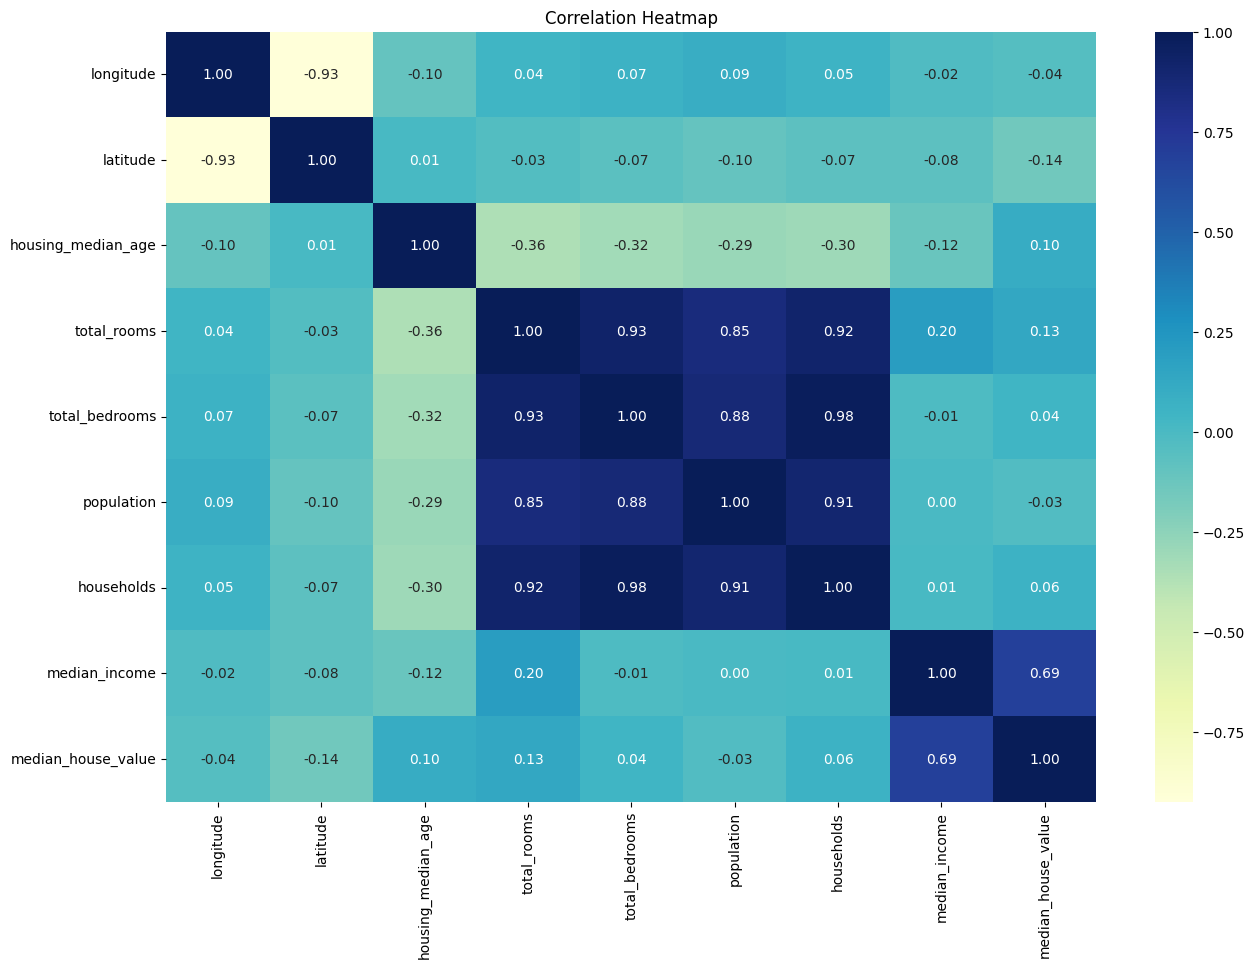

In [9]:
plt.figure(figsize=(15, 10))
plt.title('Correlation Heatmap')
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='YlGnBu', fmt='.2f')


In [10]:
train_data['total_rooms']= np.log(train_data['total_rooms'])
train_data['total_bedrooms']= np.log(train_data['total_bedrooms'])
train_data['population']= np.log(train_data['population'])
train_data['households']= np.log(train_data['households'])

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

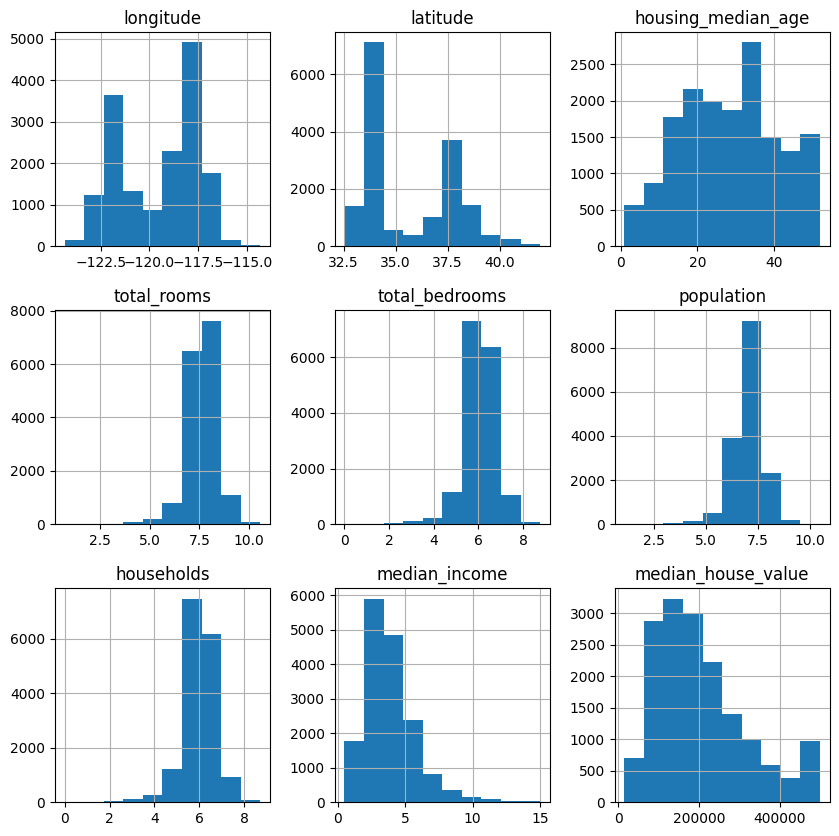

In [11]:
train_data.hist(figsize=(10,10))

## Cateorical to Binary features or numerical 

In [12]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7246
INLAND        5222
NEAR OCEAN    2068
NEAR BAY      1806
ISLAND           4
Name: count, dtype: int64

less than 1 hour from ocean- 1
else ocean_proximity=2

In [13]:
train_data=train_data.join(pd.get_dummies(train_data.ocean_proximity).astype(float)).drop(['ocean_proximity'], axis=1)

In [19]:
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12936,-121.25,38.66,26.0,8.207947,6.320768,7.387709,6.309918,5.0200,169600.0,0.0,1.0,0.0,0.0,0.0
12546,-121.50,38.54,44.0,7.062192,5.303305,6.113682,5.342334,3.7344,179800.0,0.0,1.0,0.0,0.0,0.0
18523,-122.06,36.98,15.0,8.127109,6.505784,7.359468,6.421622,4.2254,320900.0,0.0,0.0,0.0,0.0,1.0
18041,-121.98,37.22,46.0,9.219102,7.554859,8.223627,7.484930,5.2321,500001.0,1.0,0.0,0.0,0.0,0.0
3253,-120.12,36.01,18.0,7.060476,5.811141,7.020191,5.730100,2.2167,48500.0,0.0,1.0,0.0,0.0,0.0


<Axes: title={'center': 'Correlation Heatmap'}>

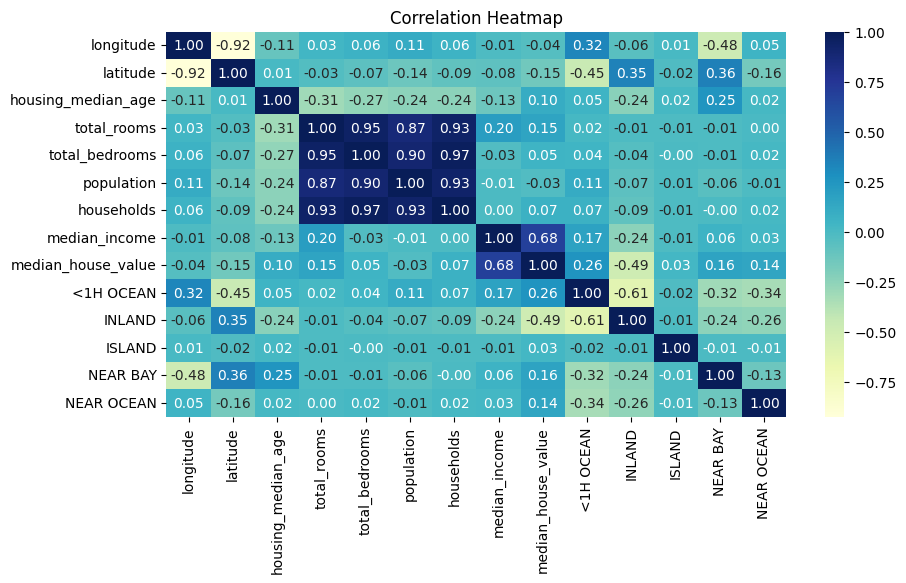

In [17]:
plt.figure(figsize=(10, 5))
plt.title('Correlation Heatmap')
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu', fmt='.2f')


<Axes: xlabel='latitude', ylabel='longitude'>

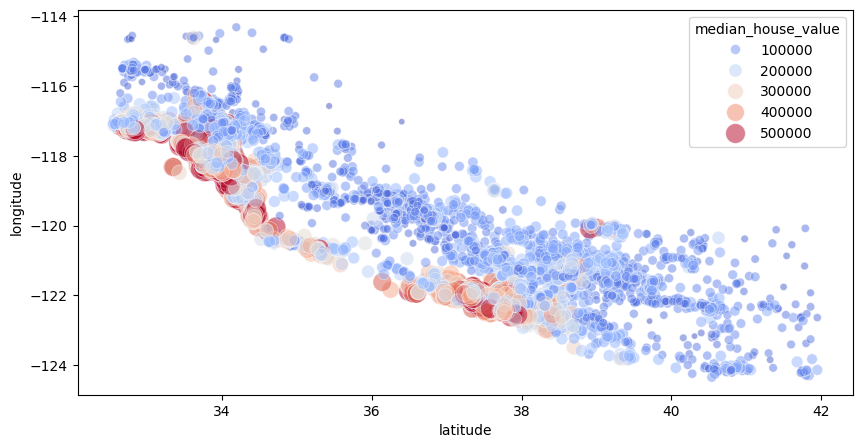

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm", size="median_house_value", sizes=(20, 200), alpha=0.5)

# Feature Engineering

In [15]:
train_data['bedroom_ratio']= train_data['total_bedrooms']/train_data['total_rooms']
train_data['households_ratio']= train_data['total_rooms']/train_data['households']

<Axes: title={'center': 'Correlation Heatmap'}>

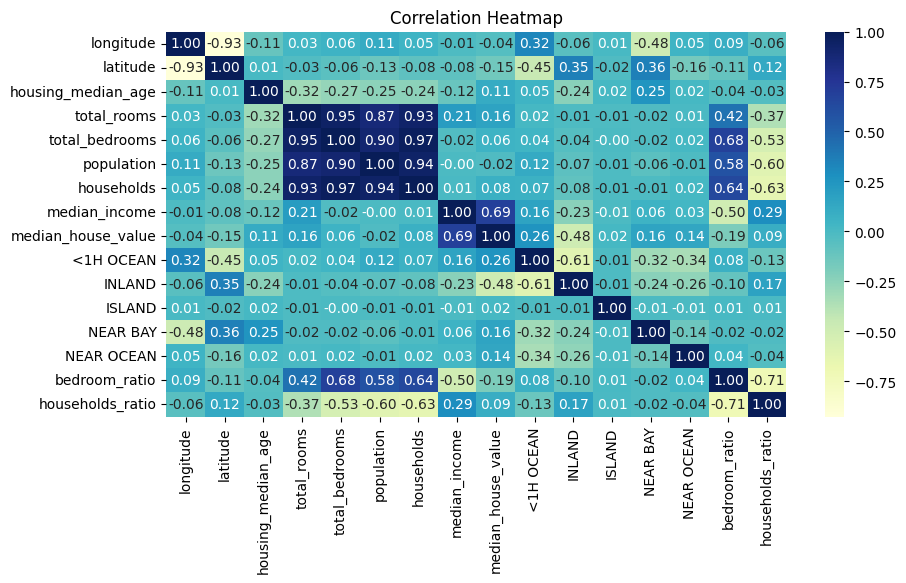

In [21]:
plt.figure(figsize=(10, 5))
plt.title('Correlation Heatmap')
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu', fmt='.2f')

# Linear Regression

In [16]:

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
# Separate features and target
X_train = train_data.drop(['median_house_value'], axis=1)
Y_train = train_data['median_house_value']

# Check shapes
print(X_train.shape, Y_train.shape)

# Replace infinite values with NaNs, then drop or fill them
X_train = X_train.replace([np.inf, -np.inf], np.nan)

# Option 1: Drop rows with NaN values
#X_train = X_train.dropna()
#Y_train = Y_train[X_train.index]  # Keep target aligned with features

# Option 2 (alternative): Fill NaNs with mean of the column
X_train = X_train.fillna(X_train.mean())
X_train_s= scaler.fit_transform(X_train)
# Fit the model
reg = LinearRegression()
reg.fit(X_train_s, Y_train)


(16346, 15) (16346,)


LinearRegression()

In [17]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,households_ratio
20024,-119.06,36.07,20.0,7.894691,6.315358,7.311218,6.306275,1.7031,0.0,1.0,0.0,0.0,0.0,0.799950,1.251879
19470,-120.99,37.67,16.0,6.342121,4.820282,5.726848,4.753590,2.1518,0.0,1.0,0.0,0.0,0.0,0.760042,1.334175
1469,-121.98,37.95,14.0,8.746716,6.749931,7.909857,6.709304,6.7371,0.0,1.0,0.0,0.0,0.0,0.771710,1.303670
2272,-119.81,36.79,39.0,7.812378,6.131226,7.019297,6.066108,2.4167,0.0,1.0,0.0,0.0,0.0,0.784809,1.287873
12711,-121.40,38.59,25.0,7.708860,6.280396,7.029973,6.175867,2.5363,0.0,1.0,0.0,0.0,0.0,0.814698,1.248223


In [27]:
X_test.shape

(4087, 9)

In [18]:
test_data= X_test.join(Y_test)

test_data['total_rooms']= np.log(test_data['total_rooms'])
test_data['total_bedrooms']= np.log(test_data['total_bedrooms'])
test_data['population']= np.log(test_data['population'])
test_data['households']= np.log(test_data['households'])

test_data=test_data.join(pd.get_dummies(test_data.ocean_proximity).astype(float)).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio']= test_data['total_bedrooms']/test_data['total_rooms']
test_data['households_ratio']= test_data['total_rooms']/test_data['households']

In [19]:
X_test = test_data.drop(['median_house_value'], axis=1)
Y_test = test_data['median_house_value']

X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.fillna(X_test.mean())

In [20]:
X_test_s= scaler.transform(X_test)


In [38]:
print(X_test_s.shape, Y_test.shape)

(4087, 15) (4087,)


In [36]:
X_test_s.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [21]:
reg.score(X_test_s, Y_test)

0.6742488615297457

# Random Forest Regression

In [23]:
from sklearn.ensemble import RandomForestRegressor

forest= RandomForestRegressor(n_estimators=100, random_state=42)
forest.fit(X_train_s,Y_train)

RandomForestRegressor(random_state=42)

In [24]:
forest.score(X_test_s,Y_test)

0.8229976428252316

In [25]:
from sklearn.model_selection import GridSearchCV
forest= RandomForestRegressor()
param_grid = {
    "n_estimators": [100,200,300],
    "max_features":[6,8,10],
    "max_depth":[15,30,40],
    
}

grid_search= GridSearchCV(forest, param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True)  
grid_search.fit(X_train_s, Y_train)

KeyboardInterrupt: 

In [1]:
best_forest=grid_search.best_estimator_
best_forest.score(X_test_s,Y_test)  

NameError: name 'grid_search' is not defined